In [ ]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)

# Colormaps that support higher numbers of categories
import colorcet as cc


# Loading Data

In [ ]:
# df = pd.read_pickle("data/df_train.pkl") # original load path. Should probably change back to this for submission. 


df = pd.read_pickle("../../../data/df_train.pkl")
df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [87]:
# Convert string embeddings to list inplace, then create numpy arrays
df_train["business_description_embedding"] = df_train["business_description_embedding"].apply(ast.literal_eval)
df_val["business_description_embedding"] = df_val["business_description_embedding"].apply(ast.literal_eval)

X_train = np.array(df_train["business_description_embedding"].tolist())
X_val = np.array(df_val["business_description_embedding"].tolist())

In [88]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012, 0.009427597, 0.006240986, 0.0177..."
15120,16504,Technology Hardware & Equipment,"[0.026561439, -0.049749356, -0.006847293, -0.0..."
23693,25893,Consumer Durables & Apparel,"[0.0115894, -0.035240766, -0.029952582, 0.0226..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

Fitting The LabelEncoder on the industry names

In [89]:
# Fit the label encoder to the classes (industry names)
label_encoder =  LabelEncoder().fit(df_train.industry)

Check if the classes contained in the validation set are also in the training set. This is important, since a model wont be able to predict for unseen classes. 

In [90]:
print(f"Train count {len(df_train.industry.unique())} Val count {len(df_val.industry.unique())}")
if all(val_label in df_val.industry.unique() for val_label in df_train.industry.unique()):
    print("All val labels are also in train set")
else:
    print("Val does NOT contain the same labels as the train set")

Train count 25 Val count 25
All val labels are also in train set


Encode the train and val labels. This encodes the industry labels with a numerical value.

In [91]:
y_train = label_encoder.transform(df_train.industry)
y_val =  label_encoder.transform(df_val.industry)
y_train

array([10, 21,  5, ..., 15,  6, 16], shape=(28535,))

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

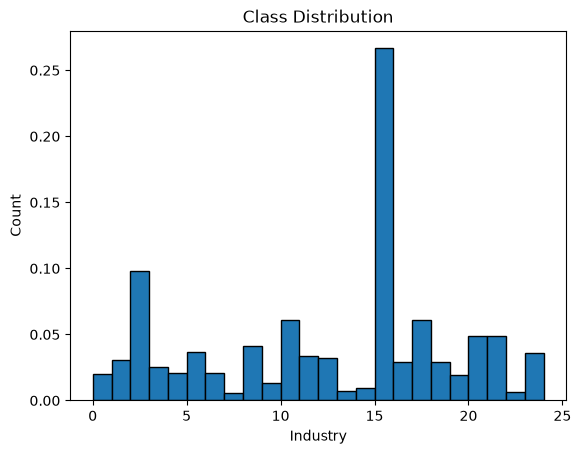

Counts per class:


industry
Materials                                         7604
Capital Goods                                     2805
Pharmaceuticals, Biotechnology & Life Sciences    1742
Financial Services                                1740
Technology Hardware & Equipment                   1390
Software & Services                               1384
Energy                                            1174
Consumer Durables & Apparel                       1037
Food, Beverage & Tobacco                           956
Health Care Equipment & Services                   911
Banks                                              874
Media & Entertainment                              827
Real Estate Management & Development               825
Commercial & Professional Services                 726
Consumer Discretionary Distribution & Retail       591
Consumer Services                                  591
Automobiles & Components                           572
Semiconductors & Semiconductor Equipment           545
T

In [92]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings
n_industries = len(np.unique(y_train))
plt.hist(y_train, bins=range(n_industries), edgecolor='black', density=True)
plt.title("Class Distribution")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()

print("Counts per class:")
df_train.industry.value_counts()

There are some industries like "materials" and "capital goods" that contain a lot more samples than others. Then there is a large middle section of industries with 500 to 1000  samples and at the end is a small numbe rof industries who have fewer than 500 samples.

Because a quarter of the samples is of the industry "materials", a naive classifier that only predicts that class can already reach an accuracy of ca. ~25%. 

To make sure that the classifier learns to predict the right class and not only that this is the majority class, we need to account for this.

This could be done through adjusting the loss function or using a classifier that can inversely weight the samples by the class's frequency.

A different approach would be to use a technique like SMOTE, or reducing the number of samples in the majority class to make it more equal. Although i think that we do want to use all the samples that we have.

Regarding if these numbers make sense. I am not 100% sure, but I think they look mostly sensible. Though since there appears to be some overlap between industries the classification could change depending on what the company views itself as, this nuance could be hard for our classifier to detect.

### PCA - Dimensionality reduction and visualization

Projected data from (28535, 768) to (28535, 2)


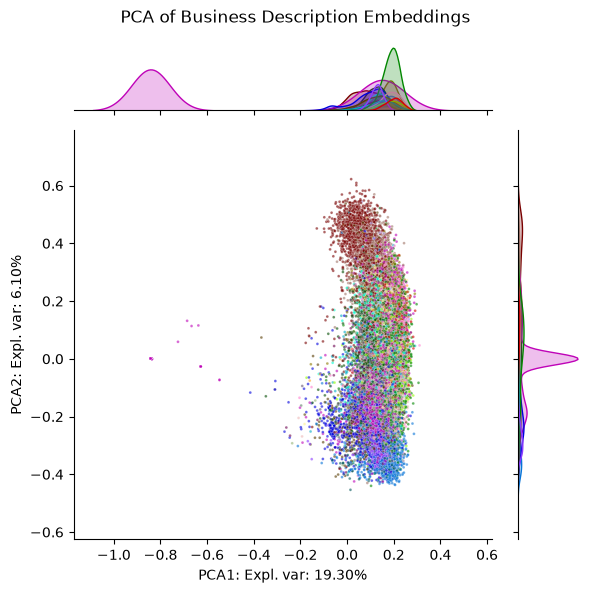

In [93]:
from seaborn.axisgrid import JointGrid
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see

# PCA 
pca_decomp = PCA(n_components=2).fit(X_train)
pca = pca_decomp.transform(X_train)
print(f"Projected data from {X_train.shape} to {pca.shape}")

# Create colormap with as many colors as there are industries
n_industries = len(np.unique(y_train))
industry_cmap = ListedColormap(cc.glasbey[:n_industries])

# Plot the first two principal components
g = sns.jointplot(x=pca[:, 0], y=pca[:, 1], hue=y_train, palette=industry_cmap, s= 4, alpha=0.6, legend=False)
#set title
g.figure.suptitle("PCA of Business Description Embeddings")
g.figure.tight_layout()
g.set_axis_labels(f"PCA1: Expl. var: {pca_decomp.explained_variance_ratio_[0] * 100:.2f}%", f"PCA2: Expl. var: {pca_decomp.explained_variance_ratio_[1] * 100:.2f}%")
plt.show()


A significant part of the distributions is centered on these outliers. But there is a second peak in PCA1 where all the other points also are. It seems like a few points there are distorting everything. These points are part of a larger group though.

It looks like there are potential outliers in the dataset or something else that distorts the result, since there are almost no points on the left side of the plot. But something needs to be there if PCA decided that that direction is most valuable to keep. 

Otherwise the data looks to be somewhat separable, although there is some overlap between classes and some are more clearly defined than others.

We will try to investigate this result further and find the reason for this distorted plot. 

It is suspected that there are a lot of very simmilar or even duplicate samples on the left side since if there were really only these ~10 points in that area, that would not be enough to distort the plot like this. 

To investigate this we look at the embeddings of the business descriptionsm, duplicates and other dimensions of the pca to see if the other dimensions look better

In [94]:
def plot_explore_pca(X_data, y_data, first_n_components = 5, title = "PCA of Business Description Embeddings in multiple pca dimensions"):
    # Get PCA of the reduced dataset
    pca_decomp = PCA(n_components=first_n_components).fit(X_data)
    pca = pca_decomp.transform(X_data)

    fig, axes = plt.subplots(first_n_components, first_n_components, figsize=(16, 16))
    plt.suptitle(title)

    for i in range(first_n_components):
        for j in range(first_n_components):
            if i == j:
                axes[i, j].set_xticks([])
                axes[i, j].set_yticks([])   
                continue

            sns.scatterplot(x=pca[:, i], y=pca[:, j], hue=y_data, palette=industry_cmap, s= 4, alpha= 0.6, ax=axes[i, j], legend=False)
            axes[i, j].set_xlabel(f"PCA{i+1}: Expl. var: {pca_decomp.explained_variance_ratio_[i] * 100:.2f}%")
            axes[i, j].set_ylabel(f"PCA{j+1}: Expl. var: {pca_decomp.explained_variance_ratio_[j] * 100:.2f}%")
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])  
 
    plt.tight_layout()
    plt.show()

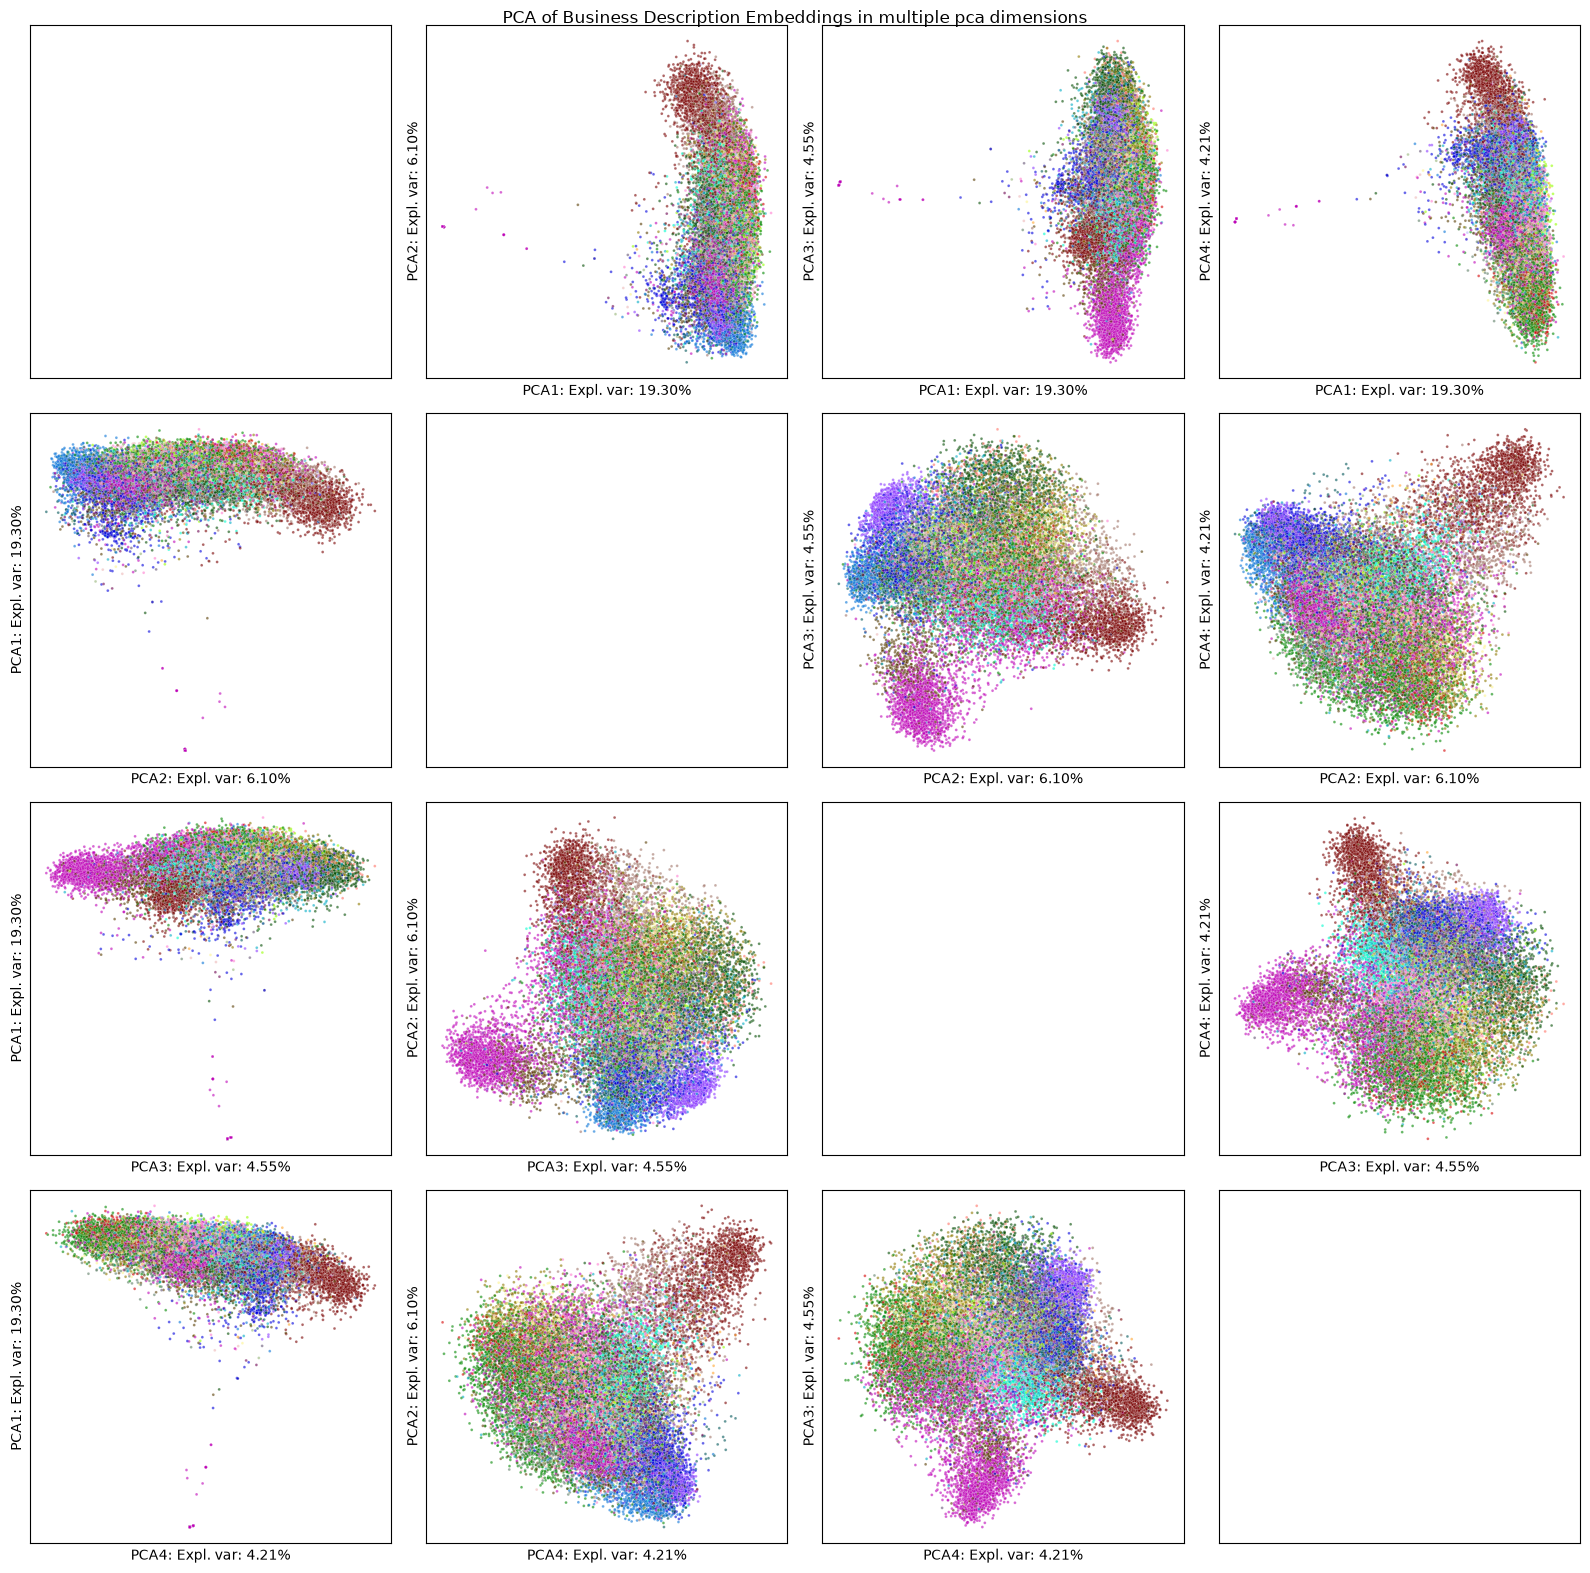

In [95]:
plot_explore_pca(X_train,y_train, first_n_components=4)

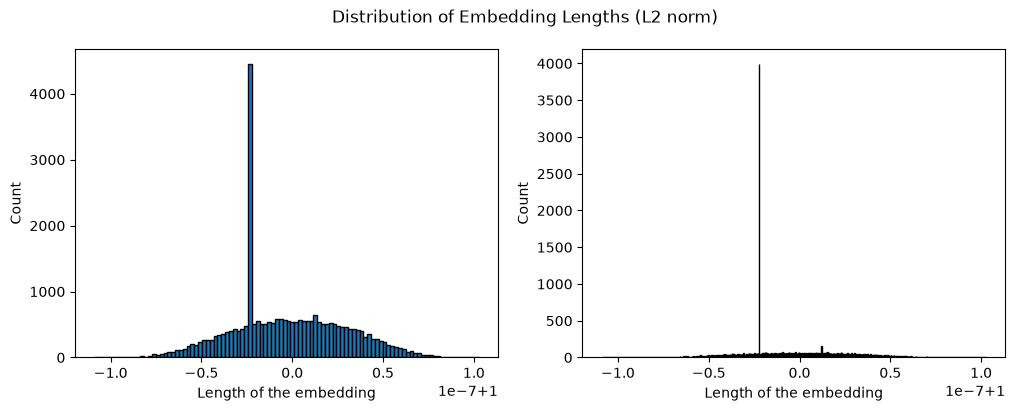

Min length:  0.9999998910388799
Max length:  1.0000001026570713


In [96]:
# Distribution of the length || x_i ||² of the business description embeddings
# If there are a lot of duplicates or near duplicates we should be able to observe that
# The plots show "negative" because it is in scientific notation. 1e-7+1 shifts it to the right.
def plot_embedding_length_distribution(embeddings: np.ndarray, title = "Distribution of Embedding Lengths (L2 norm)"):

    l2_lengths = np.linalg.norm(embeddings, axis=1, ord=2)


    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    plt.hist(l2_lengths, bins=100, edgecolor='black')
    plt.xlabel("Length of the embedding")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(l2_lengths, bins=1000, edgecolor='black')
    plt.xlabel("Length of the embedding")
    plt.ylabel("Count")
    
    plt.show()

    print("Min length: ", np.min(l2_lengths))
    print("Max length: ", np.max(l2_lengths))

plot_embedding_length_distribution(X_train)

There are a lot of duplicates or near-duplicates in the data. There is one high spike of approximately 4000 samples that are very close together (or are just the same distance from the origin).

Since they are exactly this is likely an error in the data and we should remove them. They wont give the model a good learning signal. 

We'll look at the distribution of Embedding Lengths and the PCA's again to see if it looks better.

Number of exact duplicate embeddings: 4140


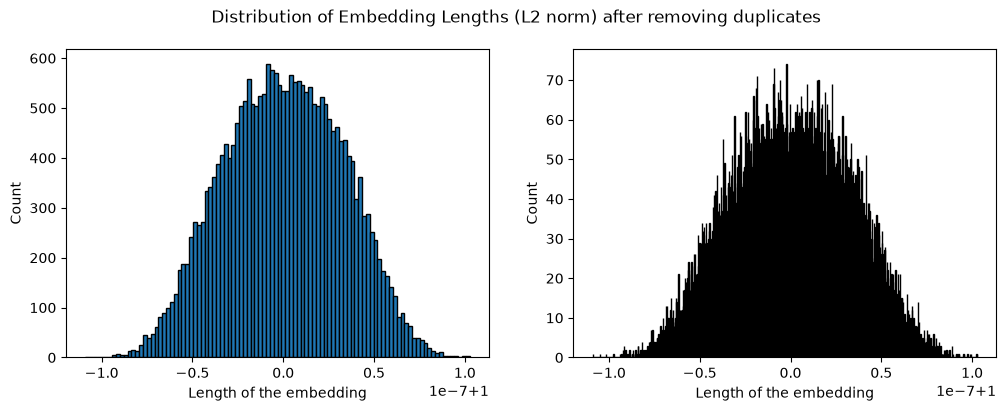

Min length:  0.9999998910388799
Max length:  1.0000001026570713


In [97]:
def remove_duplicates(df):
    # Count exact duplicates
    exact_duplicates = df.business_description_embedding.duplicated().sum()
    print(f"Number of exact duplicate embeddings: {exact_duplicates}")

    df = df.drop_duplicates(subset=['business_description_embedding'])
    return df

df_train = remove_duplicates(df_train)

# Create embeddins and labels for this reduced dataset
X_train = np.array(df_train["business_description_embedding"].tolist())
y_train = label_encoder.transform(df_train.industry)

# Dont think we need to remove duplicates from the validation set
# df_val = remove_duplicates(df_val)  
# X_val = np.array(df_val["business_description_embedding"].tolist())

plot_embedding_length_distribution(X_train, title="Distribution of Embedding Lengths (L2 norm) after removing duplicates")

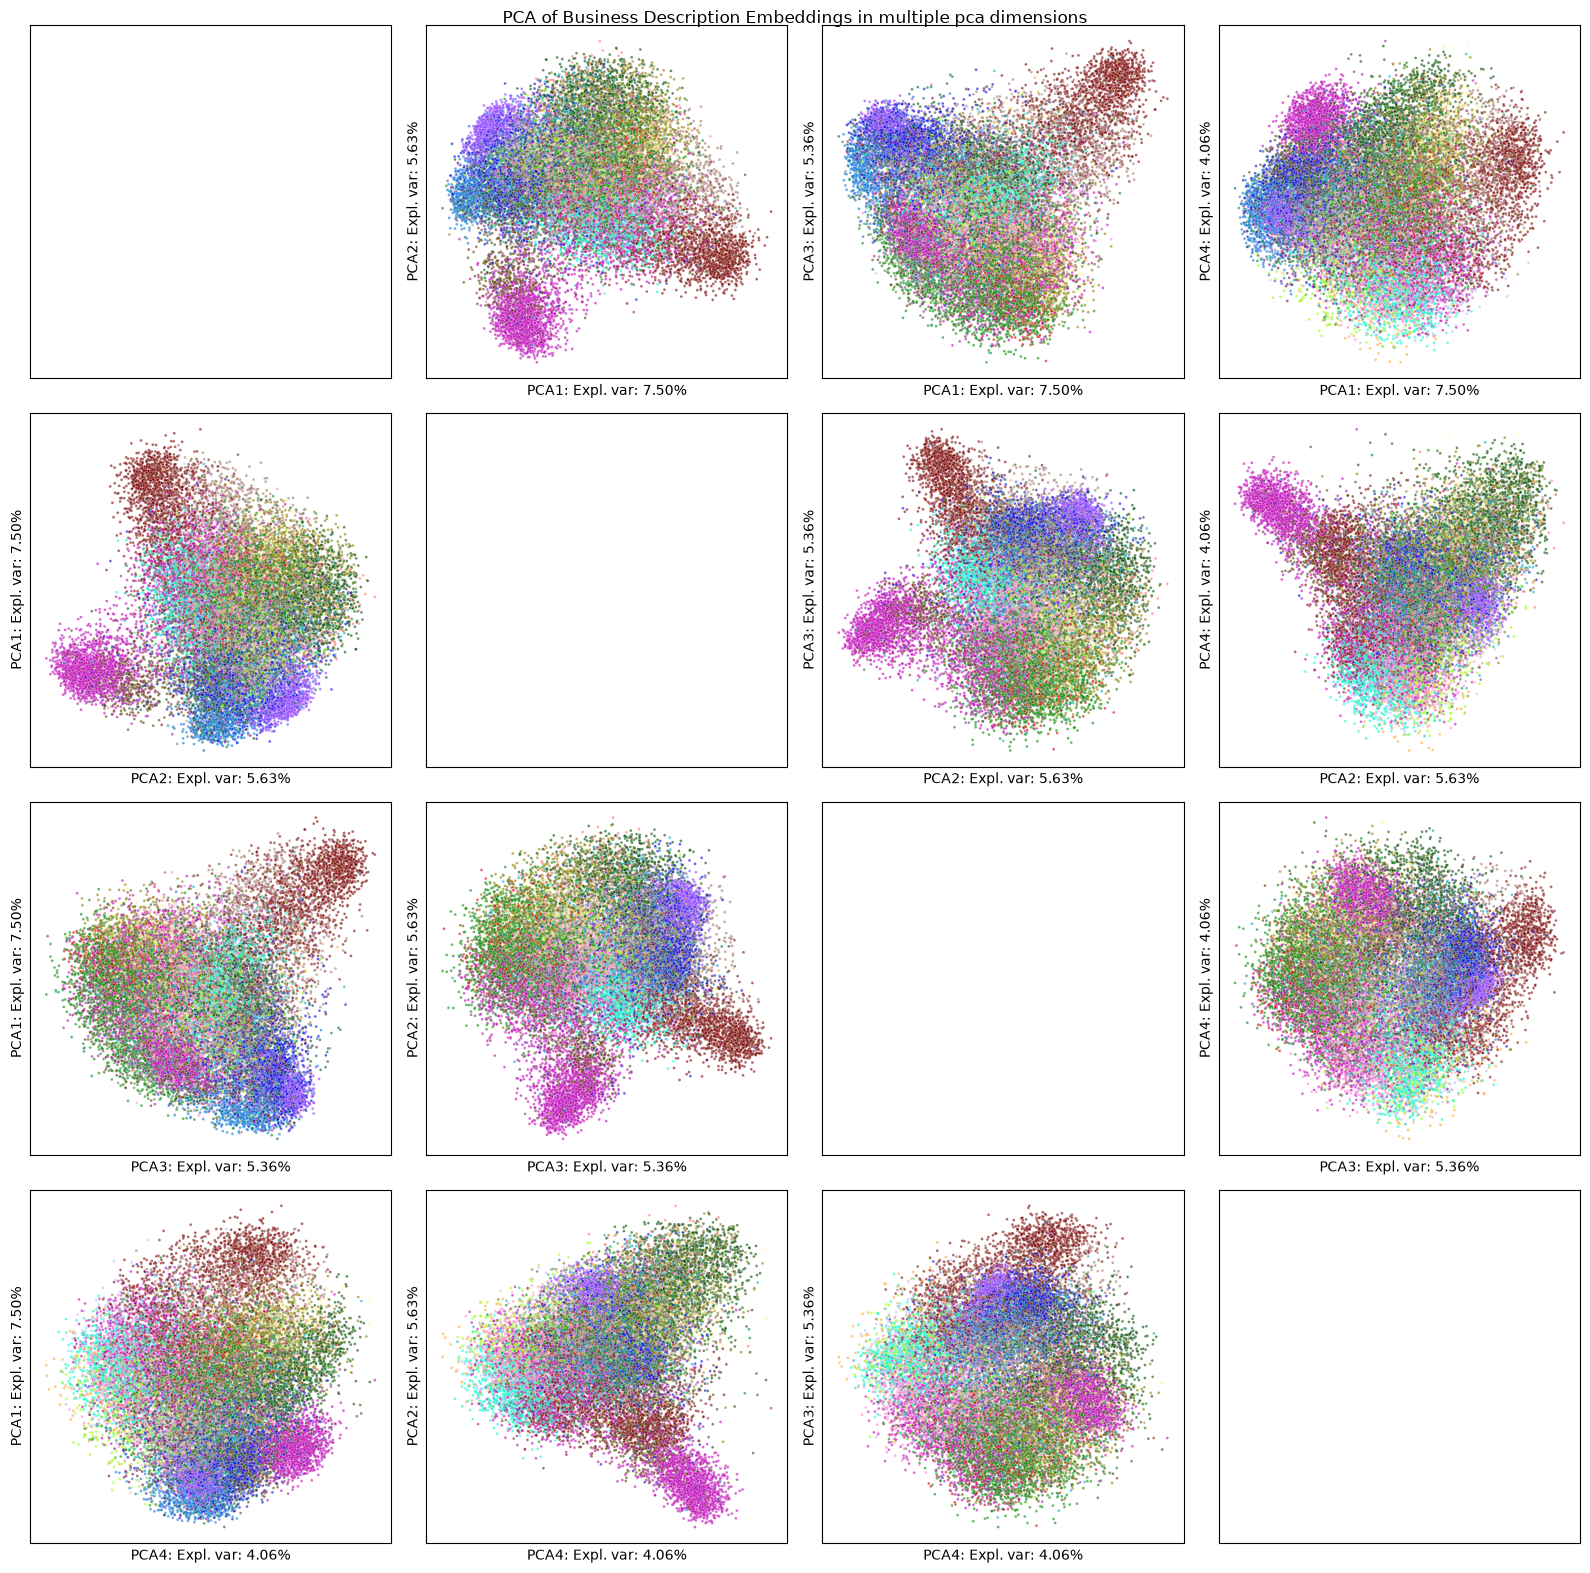

In [98]:
plot_explore_pca(X_train, y_train, first_n_components=4)

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [ ]:
# your code

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of an industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- Designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

## Scoring

Your submission is scored with the function `confidence_score` below:

$$\text{score} = F_1^{\text{weighted}}(y, \hat{y}_{pred}) \cdot \left(1 - \text{Brier}\right), \qquad \text{Brier} = \frac{1}{n}\sum_{i=1}^{n} \left(\hat{y}_{confidence}[i] - \mathbb{1}[\hat{y}_{pred}[i] = y_i]\right)^2$$

- **Weighted F1** measures how good your predicted industries are (the confidence does not enter here).
- **Brier score** measures how good your confidence is: $\hat{y}_{confidence}[i]$ should be the probability that prediction $i$ is correct.
- The Brier term is smallest when your confidence is *calibrated*: among all predictions with confidence 0.8, about 80% should be correct.
- Always reporting confidence 1.0 does not pay off (every wrong prediction costs the maximum penalty), and neither does reporting very low confidence everywhere.

In [ ]:
from sklearn.metrics import f1_score


def confidence_score(y_true, y_pred, confidence):
    """
    Score for the confidence weighted prediction task.

    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    confidence : array-like
        Confidence for each prediction, in [0, 1]
        (= estimated probability that the prediction is correct)

    Returns:
    --------
    float
        weighted F1 * (1 - Brier score), between 0 and 1 (higher is better)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence, dtype=float)

    assert len(y_true) == len(y_pred) == len(confidence), "Inputs must have the same length"
    assert np.all((confidence >= 0) & (confidence <= 1)), "Confidence must be between 0 and 1"

    f1 = f1_score(y_true, y_pred, average="weighted")
    correct = (y_true == y_pred).astype(float)
    brier = np.mean((confidence - correct) ** 2)

    return f1 * (1 - brier)

In [ ]:
# Example: evaluate a model on the validation set
# (requires y_train and y_val from the label encoding task)

example_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

y_proba = example_model.predict_proba(X_val)
y_pred = example_model.classes_[np.argmax(y_proba, axis=1)]
confidence = np.max(y_proba, axis=1)  # probability of the predicted class

print("Score with model confidence:  {:.4f}".format(confidence_score(y_val, y_pred, confidence)))
print("Score with confidence = 1.0:  {:.4f}".format(confidence_score(y_val, y_pred, np.ones(len(y_pred)))))